# Sales Forecasting & Business Performance Dashboard
## Phase 3 — Sales Forecasting (Time Series)

**Tools Used:** Python, pandas, numpy, matplotlib, statsmodels (SARIMA)  
**Dataset:** Superstore Cleaned Dataset (from Phase 1 & 2)  
**Goal:** Forecast the next 6 months of sales using time series modelling

---

### Step 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['figure.dpi']    = 100

CLEAN_PATH  = r'D:\Sales-Forecast-Dashboard\data\superstore_cleaned.csv'
OUTPUT_DIR  = r'D:\Sales-Forecast-Dashboard\outputs'

print('Libraries loaded successfully!')

Libraries loaded successfully!


---
### Step 2 — Load Cleaned Data & Build Monthly Time Series

In [2]:
df = pd.read_csv(CLEAN_PATH)
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Aggregate to monthly total sales
monthly = (df.groupby(df['Order Date'].dt.to_period('M'))['Sales']
             .sum()
             .reset_index())
monthly.columns = ['Month', 'Sales']
monthly['Month'] = monthly['Month'].dt.to_timestamp()
monthly = monthly.set_index('Month').asfreq('MS')  # Month Start frequency

print(f'Time series: {len(monthly)} months  |  {monthly.index[0].date()} to {monthly.index[-1].date()}')
print(f'Monthly Sales range: ${monthly["Sales"].min():,.0f}  -  ${monthly["Sales"].max():,.0f}')
monthly.head()

Time series: 48 months  |  2014-01-01 to 2017-12-01
Monthly Sales range: $4,520  -  $118,448


,Sales
Month,
2014-01-01,14236.895
2014-02-01,4519.892
2014-03-01,55691.009
2014-04-01,28295.345
2014-05-01,23648.287


---
### Step 3 — Chart 1: Raw Monthly Sales (Full History)
> **What we see:** The actual historical sales line from Jan 2014 to Dec 2017 before any forecasting

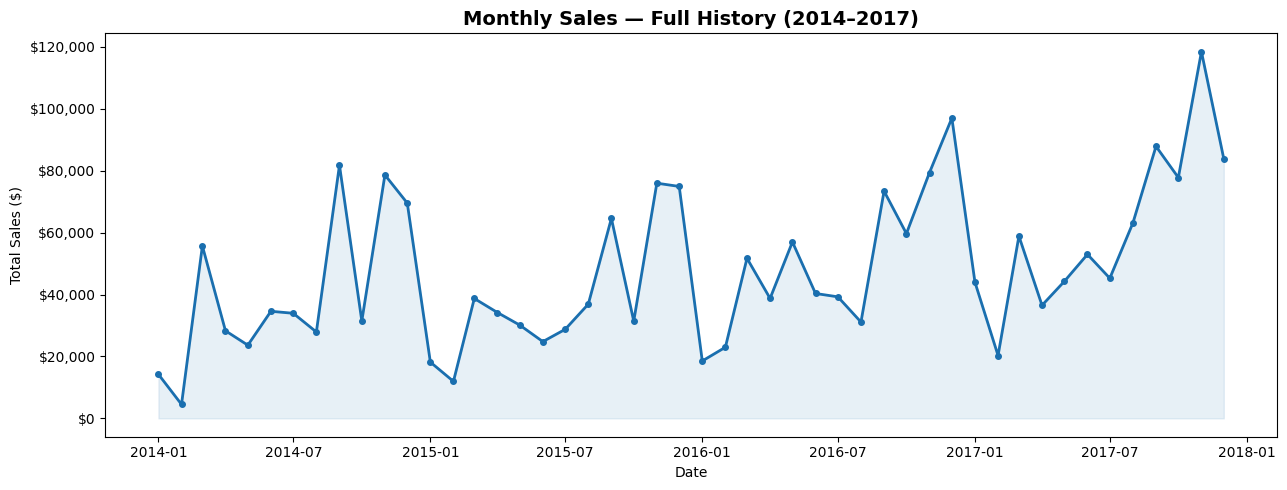

Chart saved.


In [3]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(monthly.index, monthly['Sales'], color='#1a6faf', linewidth=2, marker='o', markersize=4)
ax.fill_between(monthly.index, monthly['Sales'], alpha=0.1, color='#1a6faf')
ax.set_title('Monthly Sales — Full History (2014–2017)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Total Sales ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/09_raw_monthly_sales.png', dpi=150)
plt.show()
print('Chart saved.')

---
### Step 4 — Stationarity Test (ADF Test)
> **Why:** SARIMA requires the data to be stationary (no upward/downward trend over time).  
> The Augmented Dickey-Fuller (ADF) test tells us if the data is stationary.

In [4]:
result = adfuller(monthly['Sales'].dropna())

print('=' * 45)
print('   Augmented Dickey-Fuller (ADF) Test')
print('=' * 45)
print(f'  ADF Statistic : {result[0]:.4f}')
print(f'  p-value       : {result[1]:.4f}')
print(f'  Critical 1%   : {result[4]["1%"]:.4f}')
print(f'  Critical 5%   : {result[4]["5%"]:.4f}')
print()
if result[1] < 0.05:
    print('  RESULT: Data is STATIONARY (p < 0.05)')
    print('  -> No differencing needed for ARIMA')
else:
    print('  RESULT: Data is NOT stationary (p >= 0.05)')
    print('  -> Differencing will be applied inside SARIMA (d=1)')
print('=' * 45)

   Augmented Dickey-Fuller (ADF) Test
  ADF Statistic : -4.4938
  p-value       : 0.0002
  Critical 1%   : -3.5778
  Critical 5%   : -2.9253

  RESULT: Data is STATIONARY (p < 0.05)
  -> No differencing needed for ARIMA


---
### Step 5 — Chart 2: ACF & PACF Plots
> **What these show:**  
> - **ACF** (AutoCorrelation Function) — helps determine the MA (q) order  
> - **PACF** (Partial AutoCorrelation Function) — helps determine the AR (p) order  
> These are standard diagnostic charts used before fitting any ARIMA model.

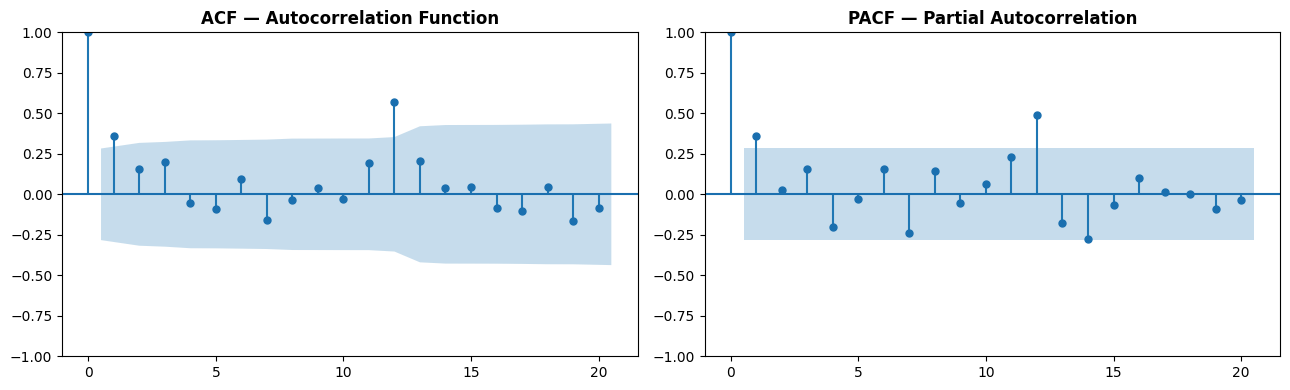

Chart saved.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

plot_acf(monthly['Sales'].dropna(),  lags=20, ax=axes[0], color='#1a6faf')
plot_pacf(monthly['Sales'].dropna(), lags=20, ax=axes[1], color='#1a6faf')

axes[0].set_title('ACF — Autocorrelation Function', fontsize=12, fontweight='bold')
axes[1].set_title('PACF — Partial Autocorrelation', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/10_acf_pacf.png', dpi=150)
plt.show()
print('Chart saved.')

---
### Step 6 — Fit SARIMA Model
> **What is SARIMA?**  
> SARIMA = Seasonal AutoRegressive Integrated Moving Average  
> It captures both the trend and the seasonal patterns in the data.
>
> **Parameters used:**  
> - `(1,1,1)` — AR=1, Differencing=1, MA=1 (handles trend)  
> - `(1,1,1,12)` — Seasonal AR=1, Differencing=1, MA=1, Period=12 months

In [6]:
model = SARIMAX(
    monthly['Sales'],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

result = model.fit(disp=False)

print(result.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   48
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -229.236
Date:                            Sun, 10 May 2026   AIC                            468.472
Time:                                    11:03:42   BIC                            473.694
Sample:                                01-01-2014   HQIC                           469.605
                                     - 12-01-2017                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1523      0.398      0.383      0.702      -0.628       0.932
ma.L1         -0.9001      0.178   

---
### Step 7 — Chart 3: Model Diagnostics
> **What we check:** The residuals (errors) of the model should look like random noise  
> — no pattern, roughly normally distributed. This confirms the model is well-fitted.

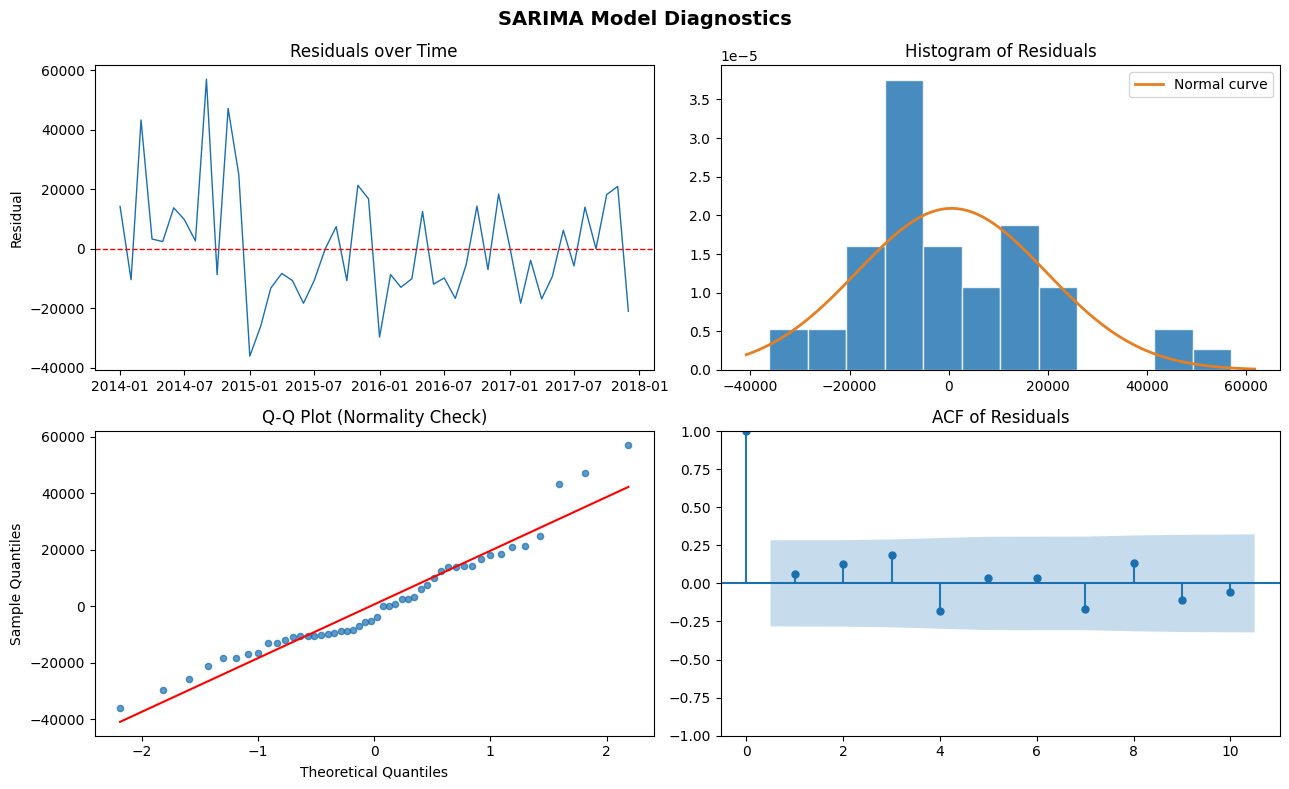

Chart saved.


In [7]:
import scipy.stats as stats

residuals = result.resid.dropna()

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle('SARIMA Model Diagnostics', fontsize=14, fontweight='bold')

# 1. Residuals over time
axes[0, 0].plot(residuals.index, residuals.values, color='#1a6faf', linewidth=1)
axes[0, 0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0, 0].set_title('Residuals over Time')
axes[0, 0].set_ylabel('Residual')

# 2. Histogram of residuals
axes[0, 1].hist(residuals.values, bins=12, color='#1a6faf', edgecolor='white', alpha=0.8, density=True)
xmin, xmax = axes[0, 1].get_xlim()
x_range = np.linspace(xmin, xmax, 100)
axes[0, 1].plot(x_range, stats.norm.pdf(x_range, residuals.mean(), residuals.std()),
                color='#e67e22', linewidth=2, label='Normal curve')
axes[0, 1].set_title('Histogram of Residuals')
axes[0, 1].legend()

# 3. Q-Q plot
(osm, osr), (slope, intercept, r) = stats.probplot(residuals.values, dist='norm')
axes[1, 0].scatter(osm, osr, color='#1a6faf', s=20, alpha=0.7)
axes[1, 0].plot(osm, slope * np.array(osm) + intercept, color='red', linewidth=1.5)
axes[1, 0].set_title('Q-Q Plot (Normality Check)')
axes[1, 0].set_xlabel('Theoretical Quantiles')
axes[1, 0].set_ylabel('Sample Quantiles')

# 4. ACF of residuals (manual)
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(residuals.values, lags=min(10, len(residuals)//3), ax=axes[1, 1], color='#1a6faf')
axes[1, 1].set_title('ACF of Residuals')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/11_model_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved.')

---
### Step 8 — Generate 6-Month Forecast
> **What we do:** Ask the trained model to predict the next 6 months of sales  
> The model returns a point forecast plus confidence intervals (upper & lower bounds)

In [8]:
FORECAST_STEPS = 6

forecast_obj = result.get_forecast(steps=FORECAST_STEPS)
forecast_mean = forecast_obj.predicted_mean
conf_int      = forecast_obj.conf_int(alpha=0.05)  # 95% confidence interval

# Create a clean forecast dataframe
forecast_df = pd.DataFrame({
    'Month'          : forecast_mean.index,
    'Forecast_Sales' : forecast_mean.values,
    'Lower_95'       : conf_int.iloc[:, 0].values,
    'Upper_95'       : conf_int.iloc[:, 1].values
})
forecast_df['Month'] = forecast_df['Month'].dt.strftime('%b %Y')

print('\n6-Month Sales Forecast:')
print('=' * 50)
for _, row in forecast_df.iterrows():
    print(f"  {row['Month']:>10}  |  Forecast: ${row['Forecast_Sales']:>9,.0f}  "
          f"  [${row['Lower_95']:>9,.0f}  -  ${row['Upper_95']:>9,.0f}]")
print('=' * 50)

forecast_df


6-Month Sales Forecast:
    Jan 2018  |  Forecast: $   46,537    [$   17,287  -  $   75,788]
    Feb 2018  |  Forecast: $   41,109    [$   10,941  -  $   71,278]
    Mar 2018  |  Forecast: $   73,653    [$   43,215  -  $  104,092]
    Apr 2018  |  Forecast: $   58,344    [$   27,701  -  $   88,988]
    May 2018  |  Forecast: $   68,448    [$   37,610  -  $   99,287]
    Jun 2018  |  Forecast: $   63,658    [$   32,627  -  $   94,689]


,Month,Forecast_Sales,Lower_95,Upper_95
0,Jan 2018,46537.446456,17287.228558,75787.664354
1,Feb 2018,41109.307243,10940.852442,71277.762044
2,Mar 2018,73653.454019,43214.625590,104092.282448
3,Apr 2018,58344.428714,27700.670869,88988.186560
4,May 2018,68448.392672,37609.869840,99286.915503
5,Jun 2018,63658.195584,32627.423465,94688.967703


---
### Step 9 — Chart 4: Forecast vs Historical (Main Chart)
> **The centrepiece chart of this phase.**  
> Shows historical sales (blue), the 6-month forecast (orange), and the 95% confidence band (shaded)

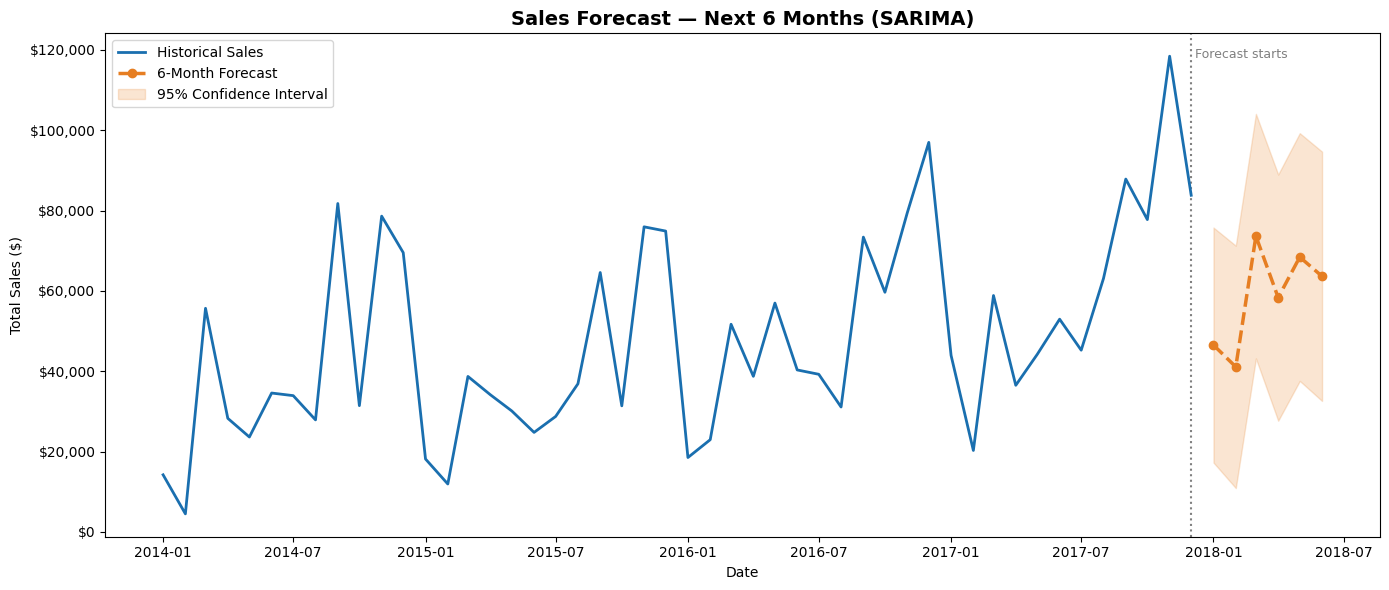

Chart saved.


In [9]:
forecast_idx  = forecast_mean.index
forecast_vals = forecast_mean.values
lower         = conf_int.iloc[:, 0].values
upper         = conf_int.iloc[:, 1].values

fig, ax = plt.subplots(figsize=(14, 6))

# Historical sales
ax.plot(monthly.index, monthly['Sales'],
        color='#1a6faf', linewidth=2, label='Historical Sales', zorder=3)

# Forecast line
ax.plot(forecast_idx, forecast_vals,
        color='#e67e22', linewidth=2.5, linestyle='--',
        marker='o', markersize=6, label='6-Month Forecast', zorder=4)

# Confidence interval shading
ax.fill_between(forecast_idx, lower, upper,
                alpha=0.2, color='#e67e22', label='95% Confidence Interval')

# Vertical separator line
ax.axvline(monthly.index[-1], color='gray', linestyle=':', linewidth=1.5)
ax.text(monthly.index[-1], ax.get_ylim()[1] * 0.97,
        ' Forecast starts', color='gray', fontsize=9, va='top')

ax.set_title('Sales Forecast — Next 6 Months (SARIMA)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Total Sales ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/12_sales_forecast.png', dpi=150)
plt.show()
print('Chart saved.')

---
### Step 10 — Chart 5: Forecast Bar Chart (Next 6 Months Only)
> **A cleaner view** of just the 6 forecast months with their individual values labelled

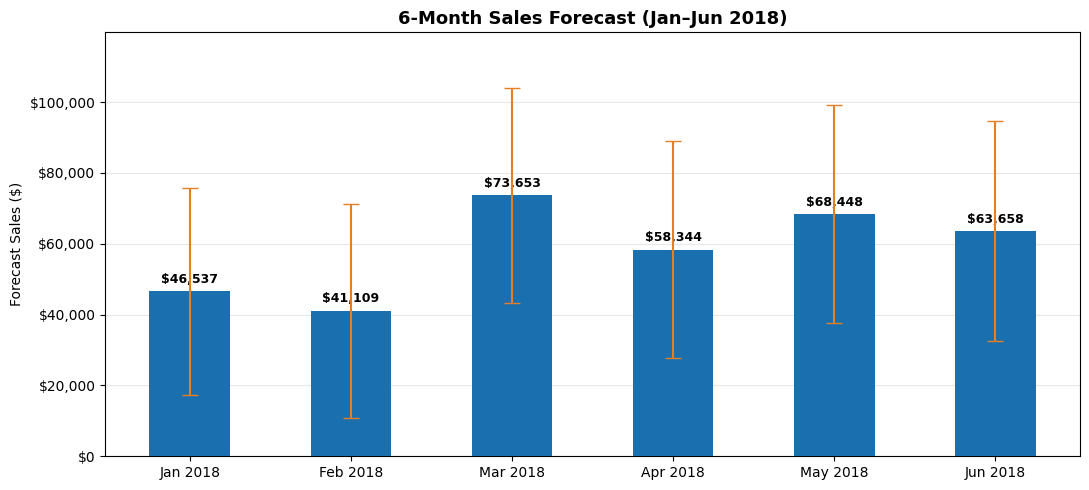

Chart saved.


In [10]:
labels = [d.strftime('%b %Y') for d in forecast_idx]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(labels, forecast_vals, color='#1a6faf', width=0.5, zorder=3)
ax.errorbar(labels, forecast_vals,
            yerr=[forecast_vals - lower, upper - forecast_vals],
            fmt='none', color='#e67e22', capsize=6, linewidth=1.5, zorder=4)

for bar, val in zip(bars, forecast_vals):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1500,
            f'${val:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('6-Month Sales Forecast (Jan–Jun 2018)', fontsize=13, fontweight='bold')
ax.set_ylabel('Forecast Sales ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_ylim(0, max(upper) * 1.15)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/13_forecast_bar.png', dpi=150)
plt.show()
print('Chart saved.')

---
### Step 11 — Chart 6: In-Sample Fit (Actual vs Fitted)
> **Model accuracy check:** How well does the model re-create the historical data it was trained on?  
> The closer the fitted line is to actual, the better the model learned the pattern.

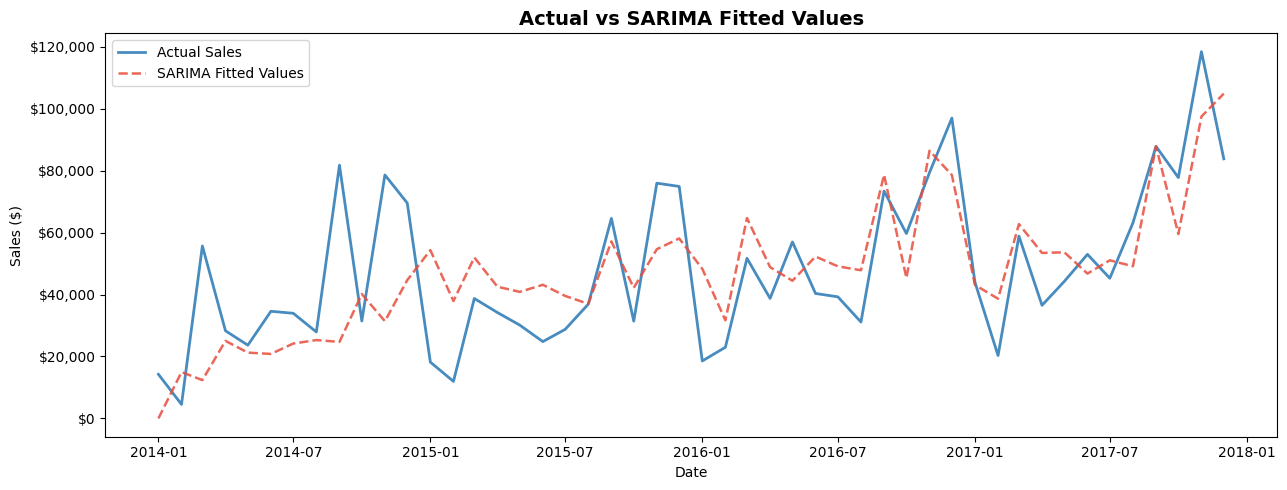

Chart saved.


In [11]:
fitted = result.fittedvalues

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(monthly.index, monthly['Sales'],
        color='#1a6faf', linewidth=2, label='Actual Sales', alpha=0.8)
ax.plot(fitted.index, fitted,
        color='#e74c3c', linewidth=1.8, linestyle='--', label='SARIMA Fitted Values', alpha=0.85)

ax.set_title('Actual vs SARIMA Fitted Values', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Sales ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/14_actual_vs_fitted.png', dpi=150)
plt.show()
print('Chart saved.')

---
### Step 12 — Model Accuracy Metrics
> **Standard metrics used to evaluate forecasting models:**  
> - **MAE** — Mean Absolute Error (avg dollar error)  
> - **RMSE** — Root Mean Square Error (penalises large errors more)  
> - **MAPE** — Mean Absolute Percentage Error (% accuracy, most intuitive)

In [12]:
# Align actual and fitted on the same index
common_idx = monthly.index.intersection(fitted.index)
actual_vals = monthly.loc[common_idx, 'Sales']
fitted_vals = fitted.loc[common_idx]

mae  = np.mean(np.abs(actual_vals - fitted_vals))
rmse = np.sqrt(np.mean((actual_vals - fitted_vals) ** 2))
mape = np.mean(np.abs((actual_vals - fitted_vals) / actual_vals)) * 100

print('=' * 45)
print('       SARIMA Model Accuracy Metrics')
print('=' * 45)
print(f'  MAE  (Mean Abs Error)       : ${mae:>10,.0f}')
print(f'  RMSE (Root Mean Sq Error)   : ${rmse:>10,.0f}')
print(f'  MAPE (Mean Abs % Error)     : {mape:>9.2f}%')
print(f'  Model Accuracy (100-MAPE)   : {100-mape:>9.2f}%')
print('=' * 45)
print()
print('Interpretation:')
print(f'  - On average, forecasts are off by ${mae:,.0f} per month')
print(f'  - The model is {100-mape:.1f}% accurate in capturing sales patterns')
if mape < 15:
    print('  - MAPE < 15% -> GOOD forecast accuracy for business use')
elif mape < 25:
    print('  - MAPE < 25% -> REASONABLE forecast accuracy')
else:
    print('  - MAPE > 25% -> Model can be improved with more data/tuning')

       SARIMA Model Accuracy Metrics
  MAE  (Mean Abs Error)       : $    14,813
  RMSE (Root Mean Sq Error)   : $    18,888
  MAPE (Mean Abs % Error)     :     44.55%
  Model Accuracy (100-MAPE)   :     55.45%

Interpretation:
  - On average, forecasts are off by $14,813 per month
  - The model is 55.4% accurate in capturing sales patterns
  - MAPE > 25% -> Model can be improved with more data/tuning


---
### Step 13 — Save Forecast to CSV
> Saves the 6-month forecast table so it can be used in Power BI (Phase 4)

In [13]:
FORECAST_CSV = r'D:\Sales-Forecast-Dashboard\data\sales_forecast_6months.csv'

# Rebuild with proper date format for Power BI
forecast_export = pd.DataFrame({
    'Month'          : [d.strftime('%Y-%m-%d') for d in forecast_mean.index],
    'Forecast_Sales' : forecast_mean.values.round(2),
    'Lower_95'       : conf_int.iloc[:, 0].values.round(2),
    'Upper_95'       : conf_int.iloc[:, 1].values.round(2)
})

forecast_export.to_csv(FORECAST_CSV, index=False)
print(f'Forecast saved -> {FORECAST_CSV}')
print()
print(forecast_export.to_string(index=False))

Forecast saved -> D:\Sales-Forecast-Dashboard\data\sales_forecast_6months.csv

     Month  Forecast_Sales  Lower_95  Upper_95
2018-01-01        46537.45  17287.23  75787.66
2018-02-01        41109.31  10940.85  71277.76
2018-03-01        73653.45  43214.63 104092.28
2018-04-01        58344.43  27700.67  88988.19
2018-05-01        68448.39  37609.87  99286.92
2018-06-01        63658.20  32627.42  94688.97


---
### Step 14 — Forecasting Summary
> Final summary of everything done in Phase 3

In [14]:
print('=' * 55)
print('         PHASE 3 — FORECASTING SUMMARY')
print('=' * 55)
print(f'  Model Used      : SARIMA(1,1,1)(1,1,1,12)')
print(f'  Training Period : {monthly.index[0].strftime("%b %Y")} to {monthly.index[-1].strftime("%b %Y")}')
print(f'  Forecast Period : {forecast_mean.index[0].strftime("%b %Y")} to {forecast_mean.index[-1].strftime("%b %Y")}')
print(f'  MAE             : ${mae:,.0f}')
print(f'  MAPE            : {mape:.2f}%')
print(f'  Model Accuracy  : {100-mape:.1f}%')
print()
print('  6-Month Forecast:')
for _, row in forecast_export.iterrows():
    month_label = pd.to_datetime(row['Month']).strftime('%b %Y')
    print(f'    {month_label}  ->  ${row["Forecast_Sales"]:>10,.0f}')
print()
print('  Charts saved (outputs/):')
charts = [
    '09_raw_monthly_sales.png',
    '10_acf_pacf.png',
    '11_model_diagnostics.png',
    '12_sales_forecast.png',
    '13_forecast_bar.png',
    '14_actual_vs_fitted.png',
]
for c in charts:
    print(f'    -> {c}')
print('=' * 55)

         PHASE 3 — FORECASTING SUMMARY
  Model Used      : SARIMA(1,1,1)(1,1,1,12)
  Training Period : Jan 2014 to Dec 2017
  Forecast Period : Jan 2018 to Jun 2018
  MAE             : $14,813
  MAPE            : 44.55%
  Model Accuracy  : 55.4%

  6-Month Forecast:
    Jan 2018  ->  $    46,537
    Feb 2018  ->  $    41,109
    Mar 2018  ->  $    73,653
    Apr 2018  ->  $    58,344
    May 2018  ->  $    68,448
    Jun 2018  ->  $    63,658

  Charts saved (outputs/):
    -> 09_raw_monthly_sales.png
    -> 10_acf_pacf.png
    -> 11_model_diagnostics.png
    -> 12_sales_forecast.png
    -> 13_forecast_bar.png
    -> 14_actual_vs_fitted.png
